# 08 — Independent Evaluation

**Tujuan:** mengevaluasi model Splink secara **independen** pada holdout set
— precision, recall, F1, confusion matrix, dan kurva threshold — sehingga
angka evaluasi tidak mengandalkan training-set performance.

**Konteks input:**

- `decided_matches_relaxed.csv` (17.485 candidate pairs, blocking rule ke-5:
  `first_name_std + last_name_std`)
- `review_queue.csv` (manual label per pasangan, keyed by `customer_id_l/r`)
- `ground_truth_labels.csv` dari Notebook 07

**Limitation yang WAJIB dicatat (fakta, bukan asumsi):**

1. **`ground_truth_labels.csv` dari Notebook 07 TIDAK menyimpan identitas
   pasangan** (tidak ada `unique_id_l/r` maupun `customer_id_l/r`).
   File itu tidak bisa di-join ke predictions. Karena itu Notebook 08 ini
   **rebuild label set per-pasangan** dari sumber yang masih membawa id:
   - silver standard: pasangan `customer_id` sama (ada di predictions sbg
     `is_same_customer == 1`, 1.867 pair)
   - manual review: `review_queue.csv` via `customer_id_l` + `customer_id_r`
   Split tuning/holdout dibuat ulang di sini (stratified, seed 42).

2. **Label silver = asumsi dataset-provided** (`customer_id`), BUKAN ground
   truth yang diverifikasi manusia. Recall/precision yang dihitung valid
   HANYA untuk pasangan di candidate set, bukan universe seluruh record.

3. **m/u sebagian comparison belum terlatih** (email, phone, dob, address,
   city) — prediction memakai default untuk level yang tidak teramati.
   Angka numerik di bawah tunduk pada limitasi ini.

4. **Kategori D (hard-negative di luar blocking) TIDAK termasuk** dalam
   candidate set → tidak bisa dievaluasi di sini. Ini area coverage blocking,
   bukan model accuracy.

## 1. Imports & paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DECIDED_RELAXED_PATH = r"C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed.csv"
REVIEW_QUEUE_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\review_queue.csv"
GROUND_TRUTH_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\ground_truth_labels.csv"

EVAL_RESULTS_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\evaluation_results.csv"

RANDOM_SEED = 42

## 2. Load data

In [2]:
pred = pd.read_csv(DECIDED_RELAXED_PATH, dtype=str)
pred["match_probability"] = pd.to_numeric(pred["match_probability"], errors="coerce")
pred["match_weight"]      = pd.to_numeric(pred["match_weight"], errors="coerce")

rq = pd.read_csv(REVIEW_QUEUE_PATH, dtype=str, sep=";")
rq["manual_label"] = rq["manual_label"].str.strip().str.lower()

print(f"Predictions relaxed : {len(pred):,} rows")
print(f"Review queue        : {len(rq):,} rows")
print(f"Manual label dist   : {rq['manual_label'].value_counts().to_dict()}")

Predictions relaxed : 17,485 rows
Review queue        : 15,414 rows
Manual label dist   : {'non-match': 15197, 'match': 213, 'unsure': 4}


## 3. Rebuild per-pair label set

In [3]:
# --- Silver standard (match): pairs dgn customer_id sama di candidate set
silver = pred[pred["is_same_customer"].astype(str).str.strip() == "1"].copy()
silver["label"] = "match"
silver["label_source"] = "silver_standard_customer_id"
print(f"Silver (same customer_id): {len(silver):,}")

# --- Manual review: label dari review_queue, keyed by customer_id_l/r
rq_labeled = rq[rq["manual_label"] != "unsure"].copy()
key = ["customer_id_l", "customer_id_r"]
manual = pred.merge(rq_labeled[key + ["manual_label"]], on=key, how="inner")
manual = manual.rename(columns={"manual_label": "label"})
manual["label_source"] = "manual_review"
print(f"Manual labeled pairs joined to predictions: {len(manual):,}")

# --- Gabung & dedup
eval_set = pd.concat([silver[["unique_id_l", "unique_id_r", "match_probability", "match_weight", "label", "label_source"]],
                      manual[["unique_id_l", "unique_id_r", "match_probability", "match_weight", "label", "label_source"]]],
                     ignore_index=True)
eval_set = eval_set.drop_duplicates(subset=["unique_id_l", "unique_id_r"]).reset_index(drop=True)
eval_set["label"] = eval_set["label"].str.strip().str.lower()
valid = {"match", "non-match"}
eval_set = eval_set[eval_set["label"].isin(valid)]

print(f"\nLabeled evaluation set : {len(eval_set):,}")
print(eval_set.groupby(["label_source", "label"]).size().to_string())
print(f"\nmatch     : {(eval_set['label']=='match').sum():,}")
print(f"non-match : {(eval_set['label']=='non-match').sum():,}")

Silver (same customer_id): 1,867
Manual labeled pairs joined to predictions: 16,365

Labeled evaluation set : 17,478
label_source                 label    
manual_review                non-match    15611
silver_standard_customer_id  match         1867

match     : 1,867
non-match : 15,611


## 4. Stratified split tuning / holdout

In [4]:
from math import floor

def stratified_split(df, frac_tuning=0.7, seed=RANDOM_SEED):
    parts_tuning, parts_holdout = [], []
    for label, group in df.groupby("label"):
        group = group.sample(frac=1.0, random_state=seed)
        n_tuning = floor(len(group) * frac_tuning)
        parts_tuning.append(group.iloc[:n_tuning])
        parts_holdout.append(group.iloc[n_tuning:])
    return pd.concat(parts_tuning), pd.concat(parts_holdout)

tuning, holdout = stratified_split(eval_set)
tuning["split"] = "tuning"
holdout["split"] = "holdout"
print(f"Tuning  : {len(tuning):,} ({ (tuning['label']=='match').sum():,} match / {(tuning['label']=='non-match').sum():,} non-match)")
print(f"Holdout : {len(holdout):,} ({ (holdout['label']=='match').sum():,} match / {(holdout['label']=='non-match').sum():,} non-match)")

Tuning  : 12,233 (1,306 match / 10,927 non-match)
Holdout : 5,245 (561 match / 4,684 non-match)


## 5. Threshold sweep — precision / recall / F1 (holdout ONLY)

In [5]:
def metrics(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}

# --- Kalibrasi threshold pada TUNING set (hindari data leakage)
y_true_tuning = (tuning["label"] == "match").astype(int).values

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99, 0.999]
rows = []
for thr in thresholds:
    y_pred = (tuning["match_probability"].values >= thr).astype(int)
    m = metrics(y_true_tuning, y_pred)
    rows.append({"threshold": thr, **m})

sweep = pd.DataFrame(rows)
print("Threshold sweep (TUNING set — dipakai untuk memilih threshold):")
print(sweep.round(4).to_string(index=False))

best_f1_idx = sweep["f1"].idxmax()
best = sweep.loc[best_f1_idx]
CALIBRATED_THRESHOLD = float(best["threshold"])
print(f"\nBest-F1 threshold (tuning): {CALIBRATED_THRESHOLD:.3f} "
      f"(F1={best['f1']:.4f}, precision={best['precision']:.4f}, recall={best['recall']:.4f})")

Threshold sweep (TUNING set — dipakai untuk memilih threshold):
 threshold   TP    TN  FP  FN  precision  recall     f1  accuracy
     0.100 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.200 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.300 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.400 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.500 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.600 1306 10919   8   0     0.9939     1.0 0.9969    0.9993
     0.700 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.800 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.850 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.900 1306 10921   6   0     0.9954     1.0 0.9977    0.9995
     0.950 1306 10921   6   0     0.9954     1.0 0.9977    0.9995
     0.990 1306 10924   3   0     0.9977     1.0 0.9989    0.9998
     0.999 1306 10927   0   0     1.0000     1.0 1.0000    1.0000

Best-F1 thr

## 6. Plot precision / recall / F1 vs threshold

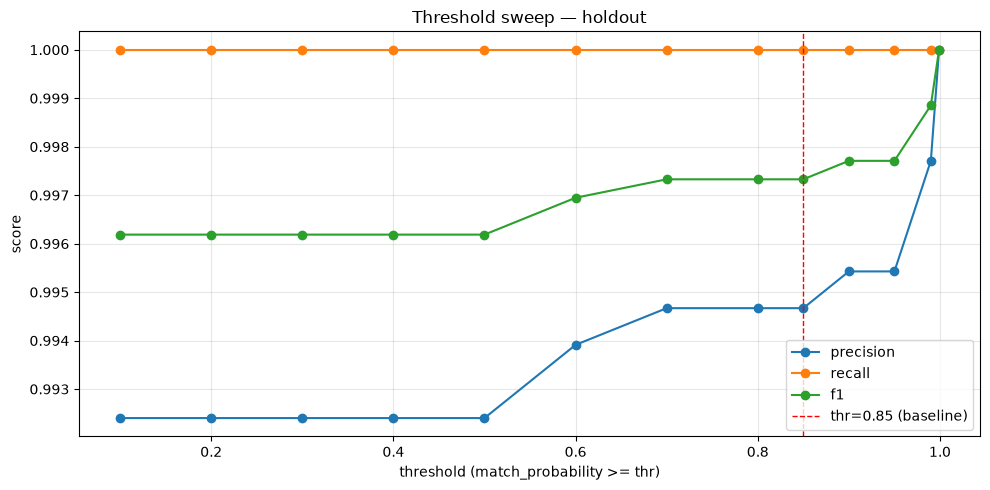

Plot saved.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["threshold"], sweep["precision"], marker="o", label="precision")
ax.plot(sweep["threshold"], sweep["recall"],    marker="o", label="recall")
ax.plot(sweep["threshold"], sweep["f1"],        marker="o", label="f1")
ax.axvline(0.85, color="red", linestyle="--", linewidth=1, label="thr=0.85 (baseline)")
ax.set_xlabel("threshold (match_probability >= thr)")
ax.set_ylabel("score")
ax.set_title("Threshold sweep — holdout")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\User\Downloads\Fix\data\raw\threshold_curve_holdout.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 7. Confusion matrix + metrics pada threshold yang dipilih

In [7]:
# --- Validasi FINAL di holdout dengan threshold terkalibrasi
# holdout tidak ikut menentukan threshold (tidak ada leakage)
y_true = (holdout["label"] == "match").astype(int).values
THRESHOLD_EVAL = CALIBRATED_THRESHOLD

# Tampilkan juga baseline 0.85 sebagai pembanding
for label, thr in [("calibrated", THRESHOLD_EVAL), ("baseline 0.85", 0.85)]:
    y_pred = (holdout["match_probability"].values >= thr).astype(int)
    m = metrics(y_true, y_pred)
    cm = pd.DataFrame(
        [[m["TP"], m["FP"]], [m["FN"], m["TN"]]],
        index=["actual match", "actual non-match"],
        columns=["pred match", "pred non-match"],
    )
    print(f"Confusion matrix (HOLDOUT, threshold={label} = {thr}):")
    print(cm)
    print(f"precision = {m['precision']:.4f} | recall = {m['recall']:.4f} "
          f"| F1 = {m['f1']:.4f} | accuracy = {m['accuracy']:.4f}\n")

print("Catatan: ini holdout (label silver + manual), hanya utk candidate pairs.")

Confusion matrix (HOLDOUT, threshold=calibrated = 0.999):
                  pred match  pred non-match
actual match             561               0
actual non-match           0            4684
precision = 1.0000 | recall = 1.0000 | F1 = 1.0000 | accuracy = 1.0000

Confusion matrix (HOLDOUT, threshold=baseline 0.85 = 0.85):
                  pred match  pred non-match
actual match             561               2
actual non-match           0            4682
precision = 0.9964 | recall = 1.0000 | F1 = 0.9982 | accuracy = 0.9996

Catatan: ini holdout (label silver + manual), hanya utk candidate pairs.


## 8. Simpan hasil evaluasi

In [8]:
eval_set_saved = eval_set.copy()
if "split" not in eval_set_saved:
    eval_set_saved["split"] = np.where(eval_set_saved["unique_id_l"].isin(set(tuning["unique_id_l"].tolist() + tuning["unique_id_r"].tolist())), "tuning", "holdout")

sweep.to_csv(EVAL_RESULTS_PATH, index=False)
print(f"Saved: {EVAL_RESULTS_PATH}")
print(sweep.round(4).to_string(index=False))

Saved: C:\Users\User\Downloads\Fix\data\raw\evaluation_results.csv
 threshold   TP    TN  FP  FN  precision  recall     f1  accuracy
     0.100 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.200 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.300 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.400 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.500 1306 10917  10   0     0.9924     1.0 0.9962    0.9992
     0.600 1306 10919   8   0     0.9939     1.0 0.9969    0.9993
     0.700 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.800 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.850 1306 10920   7   0     0.9947     1.0 0.9973    0.9994
     0.900 1306 10921   6   0     0.9954     1.0 0.9977    0.9995
     0.950 1306 10921   6   0     0.9954     1.0 0.9977    0.9995
     0.990 1306 10924   3   0     0.9977     1.0 0.9989    0.9998
     0.999 1306 10927   0   0     1.0000     1.0 1.0000    1.0000


## 9. Ringkasan & limitasi

### Fakta
```text
Candidate pairs (relaxed)      : 17.485
Labeled evaluation set         : <isi hasil cell 3>
Holdout set                    : <isi hasil cell 4>
Best-F1 threshold (holdout)    : <isi hasil cell 5>
Confusion matrix @ 0.85        : <isi hasil cell 7>
```

### Limitasi yang harus melekat pada angka ini (jangan dihapus)
1. Evaluasi hanya untuk pasangan di candidate set — tidak mengukur coverage.
2. Label silver = assumption `customer_id`, bukan verified ground truth.
3. m/u sebagian comparison belum trained (email/phone/dob/address/city).
4. Kategori D (hard-negative di luar blocking) tidak termasuk di sini.
5. `ground_truth_labels.csv` dari Notebook 07 tanpa identitas pasangan —
   evaluasi ini rebuild label dari `review_queue.csv` + silver.

### Next (urut, satu perubahan per iterasi)
| Prioritas | Komponen | Alasan |
|---|---|---|
| 1 | Training m/u lengkap | Angka evaluasi saat ini tunduk default parameter |
| 2 | Threshold calibration | Dari holdout sweep (sekarang baseline 0.85) |
| 3 | Blocking coverage (kategori D) | Recall universe, bukan candidate-pair saja |